<a href="https://colab.research.google.com/github/RosisDn/ml-lab-course/blob/main/PROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files
uploaded = files.upload()

Saving tmdb_5000_credits.csv to tmdb_5000_credits.csv
Saving tmdb_5000_movies.csv to tmdb_5000_movies.csv


In [4]:
# Importing related libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from wordcloud import WordCloud # For most repeated words
import json


In [ ]:
#

In [5]:
# Importing the datasets
# We load the two CSV files into dataframes.
# credits_df contains cast and crew information for each movie.
# movies_df contains movie details such as budget, revenue, genres and popularity.
credits_df=pd.read_csv('tmdb_5000_credits.csv')
movies_df=pd.read_csv('tmdb_5000_movies.csv')

In [6]:
#slide 4
# Merging
# We rename the columns in credits_df to make them cleaner and easier to work with.
# Then we merge both dataframes on the 'id' column so that each movie
# has both its metadata and cast/crew information in one single dataframe.
credits_df.columns = ['id','tittle','cast','crew']
df= credits_df.merge(movies_df,on='id')

In [7]:

## Inspecting the merged dataframez
# We use df.info() to get an overview of the dataset.
# This shows us column names, data types and how many non-null values each column has.
# It helps us identify missing values and understand the structure of our data.
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4803 entries, 0 to 4802
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    4803 non-null   int64  
 1   tittle                4803 non-null   object 
 2   cast                  4803 non-null   object 
 3   crew                  4803 non-null   object 
 4   budget                4803 non-null   int64  
 5   genres                4803 non-null   object 
 6   homepage              1712 non-null   object 
 7   keywords              4803 non-null   object 
 8   original_language     4803 non-null   object 
 9   original_title        4803 non-null   object 
 10  overview              4800 non-null   object 
 11  popularity            4803 non-null   float64
 12  production_companies  4803 non-null   object 
 13  production_countries  4803 non-null   object 
 14  release_date          4802 non-null   object 
 15  revenue              

Data Cleaning and Preprocessing

In [8]:
#slide 6
#EDA means exploring and understanding your data before building any model.
#What: Makes a copy of the original data.
#Why: We never want to destroy the original. If we make a mistake while cleaning, we can always go back.
# Think of it like making a copy of a document before editing it.
df_EDA = df.copy(deep=True)

#What: Counts how many empty values exist in each column.
#Why: We need to know where the problems are before we can fix them. The result looks like this:
df_EDA.isnull().sum()

,0
id,0
tittle,0
cast,0
crew,0
budget,0
genres,0
homepage,3091
keywords,0
original_language,0
original_title,0


In [9]:
#slide 6
# Dropping the unrelated info for the EDA
#What: Completely removes 6 columns.
#Why: These columns do not help the model predict success:

#homepage — 3091 missing values, useless
#tagline — 844 missing values, useless
#id — just a number, tells us nothing
#overview — long text, hard for the model to use
#original_title & tittle — movie names are not needed for prediction
df_EDA.drop(['homepage', 'tagline', 'id', 'overview', 'original_title', 'tittle'] ,axis = 1,inplace = True)

In [10]:
#slide 6
# Replacing the 2 null runtimes with the mean of all movies
#What: The 2 movies that have no runtime get the average runtime of all movies (~102 min).
#Why: Instead of deleting these movies completely, we give them the average value.
#These movies still have other useful information so it would be a waste to remove them entirely.
df_EDA['runtime'] = df_EDA['runtime'].fillna(df_EDA['runtime'].mean())

In [11]:
# Removing any NaN
#What: Removes all rows that still have empty values.
#Why: Machine learning models cannot handle empty values — they either crash or give wrong results.
#We already saved the important rows in Step 4, now we remove the rest that cannot be fixed.
df_EDA = df_EDA.dropna()
# Removing any Duplicates
#What: Removes rows that are exactly the same.
#Why: If the same movie appears twice, the model thinks that movie is more important than others and learns the wrong patterns.
# It is like counting the same answer twice on an exam.
df_EDA = df_EDA.drop_duplicates()
# Counting the null values in each attribute
df_EDA.isnull().sum()

,0
cast,0
crew,0
budget,0
genres,0
keywords,0
original_language,0
popularity,0
production_companies,0
production_countries,0
release_date,0


In [12]:
#slide 4
# Creating a Year feature for easier analysis
#What: Converts the release date from text into just a year number.
#Why: The model does not understand "2012-05-14" but it does understand "2012". A year as a number is much easier for the model to work with and allows us to analyze trends over time.
df_EDA['release_date'] = pd.to_datetime(df_EDA['release_date'])
df_EDA['year'] = df_EDA['release_date'].dt.year
df_EDA['year']

,year
0,2009
1,2007
2,2015
3,2012
4,2012
...,...
4798,1992
4799,2011
4800,2013
4801,2012


In [13]:
#slide 2 & 3
# Creating a profit and is_profitable feature for easier analysis
#What: Calculates the profit for each movie and creates a yes/no column for whether it made money.
#Why: The original data has budget and revenue separately but not profit.
#We need profit to later decide what makes a movie successful.
#Simple as:
df_EDA['profit'] = df_EDA['revenue'] - df_EDA['budget']
df_EDA['is_profitable'] = df_EDA['profit'] > 0


In [14]:
# A simple Overview

# We use df_EDA.info() to get a quick summary of the dataset after cleaning.
# This shows us the column names, data types, and how many non-null values each column has.
# It helps us confirm that the cleaning steps worked correctly.
df_EDA.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4802 entries, 0 to 4802
Data columns (total 20 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   cast                  4802 non-null   object        
 1   crew                  4802 non-null   object        
 2   budget                4802 non-null   int64         
 3   genres                4802 non-null   object        
 4   keywords              4802 non-null   object        
 5   original_language     4802 non-null   object        
 6   popularity            4802 non-null   float64       
 7   production_companies  4802 non-null   object        
 8   production_countries  4802 non-null   object        
 9   release_date          4802 non-null   datetime64[ns]
 10  revenue               4802 non-null   int64         
 11  runtime               4802 non-null   float64       
 12  spoken_languages      4802 non-null   object        
 13  status                4

In [15]:
# Head of the DF
# We use df_EDA.head(5) to display the first 5 rows of the cleaned dataset.
# This gives us a visual confirmation of what the data looks like after all the preprocessing steps.
# We can see the new columns we created such as profit, is_profitable and year.
df_EDA.head(5)

,cast,crew,budget,genres,keywords,original_language,popularity,production_companies,production_countries,release_date,revenue,runtime,spoken_languages,status,title,vote_average,vote_count,year,profit,is_profitable
0,"[{""cast_id"": 242, ""character"": ""Jake Sully"", ""...","[{""credit_id"": ""52fe48009251416c750aca23"", ""de...",237000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 1463, ""name"": ""culture clash""}, {""id"":...",en,150.437577,"[{""name"": ""Ingenious Film Partners"", ""id"": 289...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2009-12-10,2787965087,162.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}, {""iso...",Released,Avatar,7.2,11800,2009,2550965087,True
1,"[{""cast_id"": 4, ""character"": ""Captain Jack Spa...","[{""credit_id"": ""52fe4232c3a36847f800b579"", ""de...",300000000,"[{""id"": 12, ""name"": ""Adventure""}, {""id"": 14, ""...","[{""id"": 270, ""name"": ""ocean""}, {""id"": 726, ""na...",en,139.082615,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2007-05-19,961000000,169.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,Pirates of the Caribbean: At World's End,6.9,4500,2007,661000000,True
2,"[{""cast_id"": 1, ""character"": ""James Bond"", ""cr...","[{""credit_id"": ""54805967c3a36829b5002c41"", ""de...",245000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 470, ""name"": ""spy""}, {""id"": 818, ""name...",en,107.376788,"[{""name"": ""Columbia Pictures"", ""id"": 5}, {""nam...","[{""iso_3166_1"": ""GB"", ""name"": ""United Kingdom""...",2015-10-26,880674609,148.0,"[{""iso_639_1"": ""fr"", ""name"": ""Fran\u00e7ais""},...",Released,Spectre,6.3,4466,2015,635674609,True
3,"[{""cast_id"": 2, ""character"": ""Bruce Wayne / Ba...","[{""credit_id"": ""52fe4781c3a36847f81398c3"", ""de...",250000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 80, ""nam...","[{""id"": 849, ""name"": ""dc comics""}, {""id"": 853,...",en,112.312950,"[{""name"": ""Legendary Pictures"", ""id"": 923}, {""...","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-07-16,1084939099,165.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,The Dark Knight Rises,7.6,9106,2012,834939099,True
4,"[{""cast_id"": 5, ""character"": ""John Carter"", ""c...","[{""credit_id"": ""52fe479ac3a36847f813eaa3"", ""de...",260000000,"[{""id"": 28, ""name"": ""Action""}, {""id"": 12, ""nam...","[{""id"": 818, ""name"": ""based on novel""}, {""id"":...",en,43.926995,"[{""name"": ""Walt Disney Pictures"", ""id"": 2}]","[{""iso_3166_1"": ""US"", ""name"": ""United States o...",2012-03-07,284139100,132.0,"[{""iso_639_1"": ""en"", ""name"": ""English""}]",Released,John Carter,6.1,2124,2012,24139100,True


EDA (Exploratory Data Analysis)

In [16]:
# Overview
# Q0 : First overview.
# We use df_EDA.describe() to get statistical information about the dataset.
# This shows us the mean, min, max and standard deviation of each numerical column.
# It helps us understand the range and distribution of our data.
df_EDA.describe()


,budget,popularity,release_date,revenue,runtime,vote_average,vote_count,year,profit
count,4.802000e+03,4802.000000,4802,4.802000e+03,4802.000000,4802.000000,4802.000000,4802.000000,4.802000e+03
mean,2.905109e+07,21.496776,2002-12-27 23:45:54.352353280,8.227777e+07,106.898116,6.093440,690.361724,2002.468763,5.322668e+07
min,0.000000e+00,0.000372,1916-09-04 00:00:00,0.000000e+00,0.000000,0.000000,0.000000,1916.000000,-1.657101e+08
25%,8.000000e+05,4.671734,1999-07-14 00:00:00,0.000000e+00,94.000000,5.600000,54.000000,1999.000000,-7.997688e+05
50%,1.500000e+07,12.924931,2005-10-03 00:00:00,1.917498e+07,103.500000,6.200000,235.500000,2005.000000,2.529443e+06
75%,4.000000e+07,28.332017,2011-02-16 00:00:00,9.291920e+07,117.750000,6.800000,737.000000,2011.000000,5.533980e+07
max,3.800000e+08,875.581305,2017-02-03 00:00:00,2.787965e+09,338.000000,10.000000,13752.000000,2017.000000,2.550965e+09
std,4.072447e+07,31.818451,NaN,1.628697e+08,22.556893,1.191496,1234.674268,12.414354,1.359797e+08


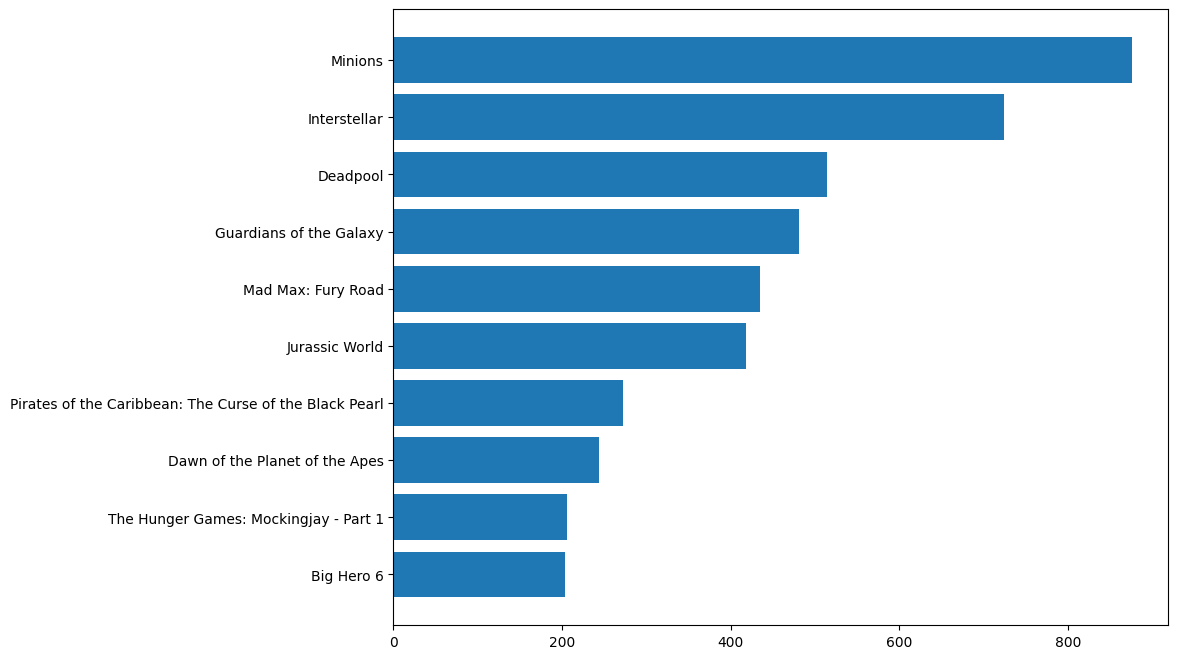

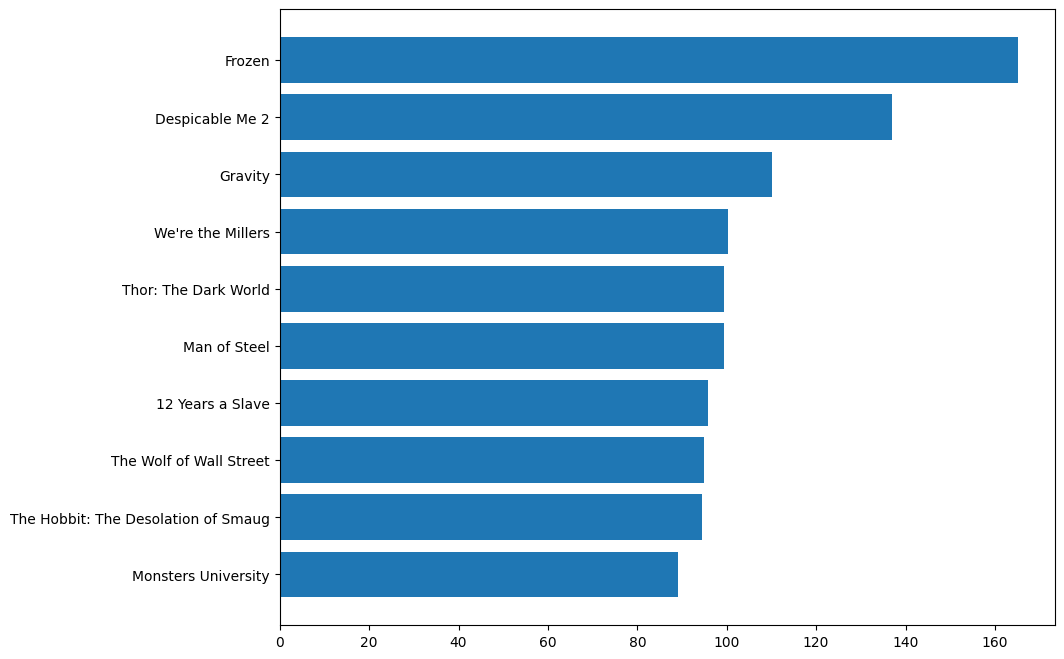

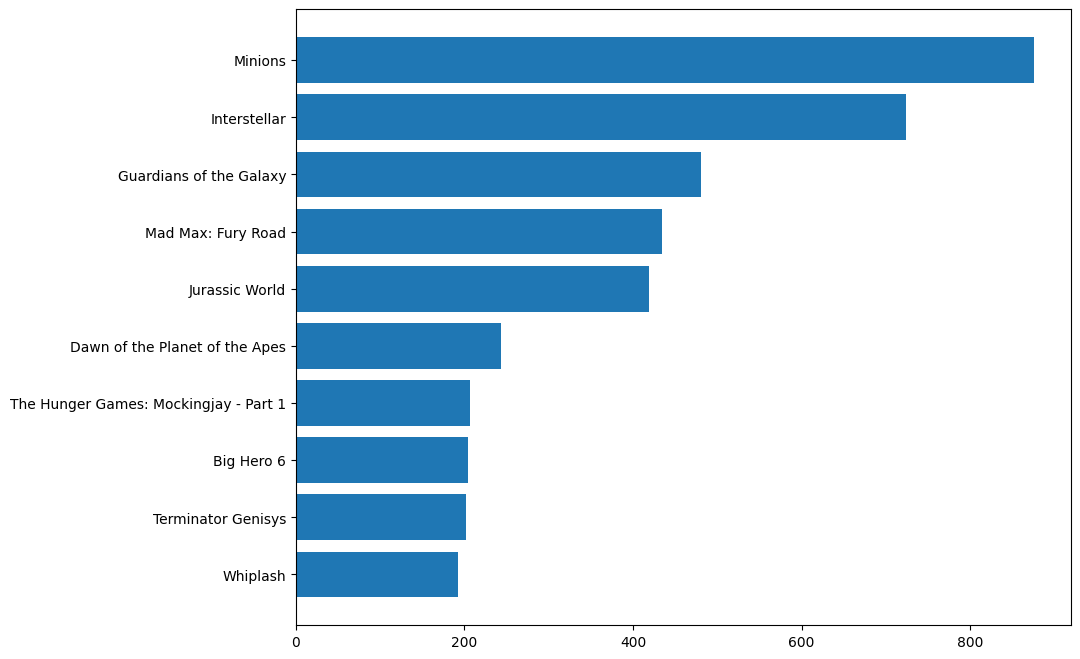

In [17]:
#slide 5
# Q1 : Which movie have high popularity over all years ?
# We define a function that sorts movies by popularity and plots the top 10.
# We can also filter by a specific year or year range.
# This helps us understand which movies were the most popular overall and in specific time periods.
def find_popularity(year_1 = 0 , year_2 = 0) :
 sorted_popularity = df_EDA.sort_values(by = 'popularity',ascending= False)
 if year_2 == 0 :
  year_2 = year_1
 if year_1 != 0 :
  sorted_popularity.query('year >= @year_1 and year <= @year_2',inplace = True)
 plt.subplots(figsize=(10,8))
 plt.gca().invert_yaxis()
 plt.barh(sorted_popularity['title'].head(10),sorted_popularity['popularity'].head(10))

find_popularity()     # # Top 10 most popular movies overall
find_popularity(2013) # 10 most popular For the year == 2013
find_popularity(2013,2015) # 10 most popular For the 2013 <= year <= 2015


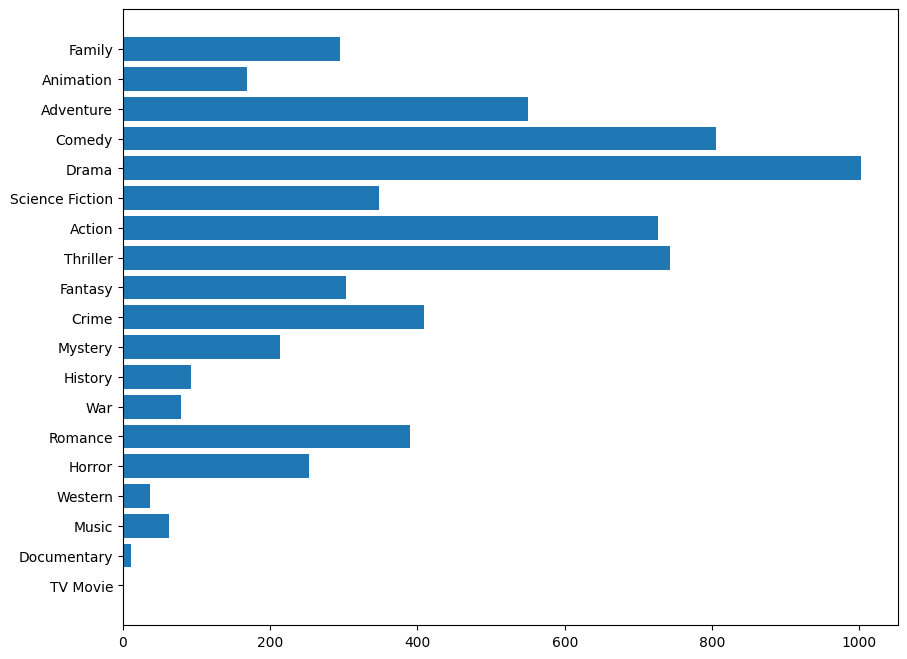

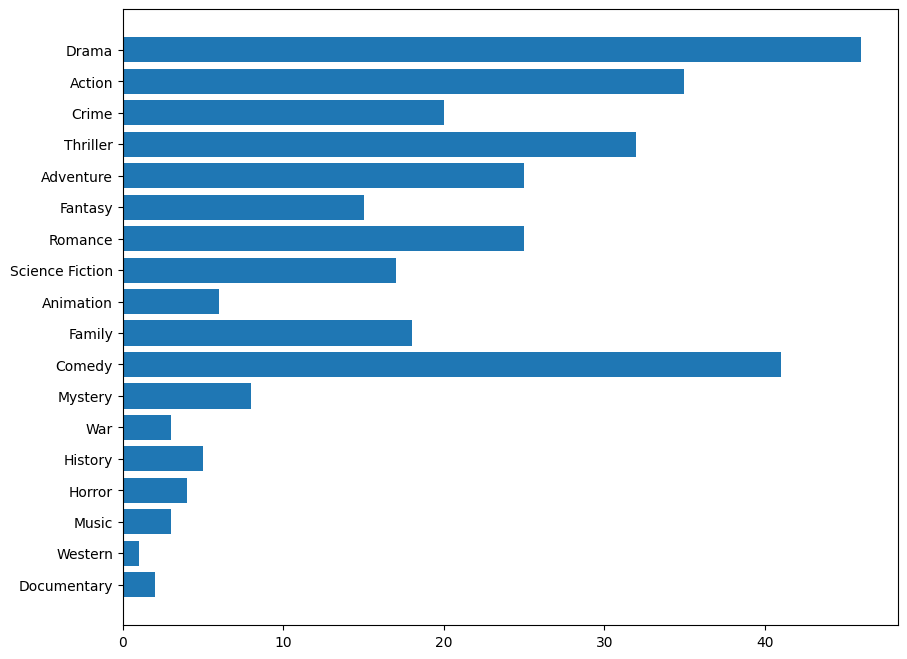

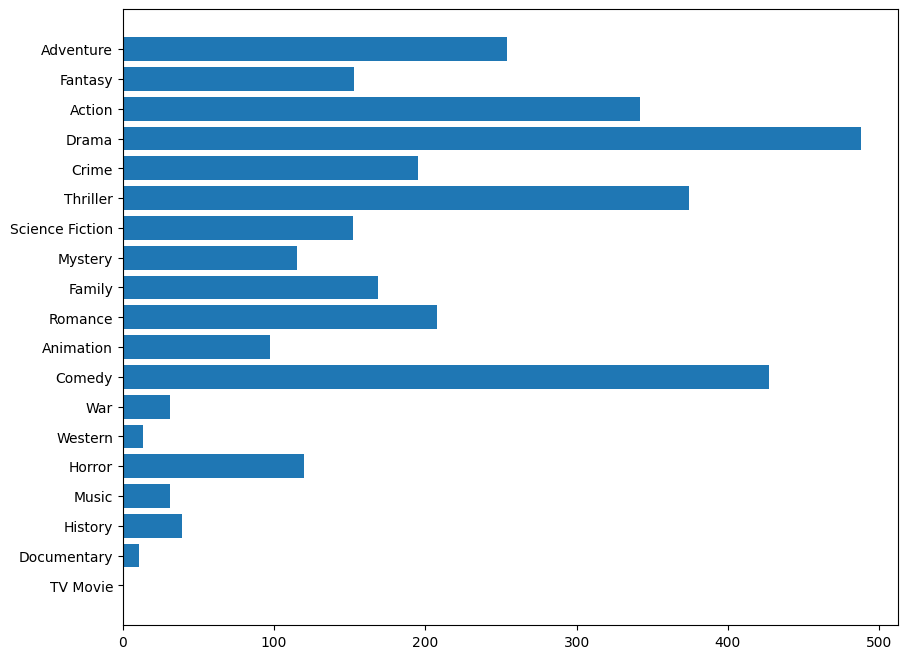

In [18]:
#slide 5
# Q2 : Which Genres have high popularity over all years ?
# We define a function that extracts genres from the JSON column
# and counts which genres appear most in the top half of popular movies.
# This helps us understand which genres are most associated with popular films.
def find_genres(year_1 = 0 , year_2 = 0) :
    sorted_popularity = df_EDA.sort_values(by = 'popularity',ascending= False)
    if year_2 == 0 :
        year_2 = year_1
    if year_1 != 0 :
        sorted_popularity.query('year >= @year_1 and year <= @year_2',inplace = True)
    z = list()
    counter = 0
    for i in sorted_popularity['genres'] :
        i = json.loads(i)
        for dic in i :
            dict(dic)
            z.append(dic.get('name'))
        counter +=1
        if counter >= sorted_popularity['genres'].shape[0]/2 :
            break
    unique_genres = set(z)
    counts = dict()
    for i in z:
        counts[i] = counts.get(i, 0) + 1
    plt.subplots(figsize=(10,8))
    plt.gca().invert_yaxis()
    plt.barh(list(counts.keys()),list(counts.values()))

find_genres()           # Most popular genres overall
find_genres(2008)       # Most popular genres in 2008
find_genres(2002,2012)  # Most popular genres between 2002 and 2012

In [19]:
# Q3 : Which companies make the high revenues?
# We split the movies into high and low revenue groups based on the median revenue.
# Then we extract the production companies from the JSON column for high revenue movies.
# This helps us identify which studios are most associated with financial success.
sorted_revenues = df_EDA.sort_values(by = 'revenue',ascending= False)
low_revenues = df_EDA[df_EDA['revenue'] < df_EDA['revenue'].median()]
high_revenues = df_EDA[df_EDA['revenue'] >= df_EDA['revenue'].median()]
z = list()
for i in high_revenues['production_companies'] :
    i = json.loads(i)
    for dic in i :
        dict(dic)
        z.append(dic.get('name'))
unique_genres = set(z)
counts = dict()
for i in z:
    counts[i] = counts.get(i, 0) + 1
s = pd.DataFrame(list(counts.values()),list(counts.keys()),columns=['counts'])
s = s.sort_values(by='counts',ascending= False)
print(s)

                                        counts
Universal Pictures                         244
Warner Bros.                               243
Paramount Pictures                         211
Twentieth Century Fox Film Corporation     177
Columbia Pictures                          151
...                                        ...
Samson Films                                 1
Crossroads                                   1
Mad Max Films                                1
Carnival Films                               1
Napoleon Pictures Limited                    1

[2642 rows x 1 columns]


In [20]:
# Q4 : Which production companies have produced most films?
# We extract all production companies from the JSON column and count how many films each has produced.
# We then display the top 5 companies with the most productions.
companies_list = []
for companies_str in df_EDA['production_companies']:
    data = json.loads(companies_str)
    names = [item['name'] for item in data]
    companies_list.extend(names)
companies_count = {i:companies_list.count(i) for i in companies_list}
sorted_companies_count = dict(sorted(companies_count.items(), key=lambda item: item[1], reverse=True))
for i, (company, count) in enumerate(sorted_companies_count.items()):
    if i < 5:
        print(f"{company}: {count}")
    else:
        break

Warner Bros.: 319
Universal Pictures: 311
Paramount Pictures: 285
Twentieth Century Fox Film Corporation: 222
Columbia Pictures: 201


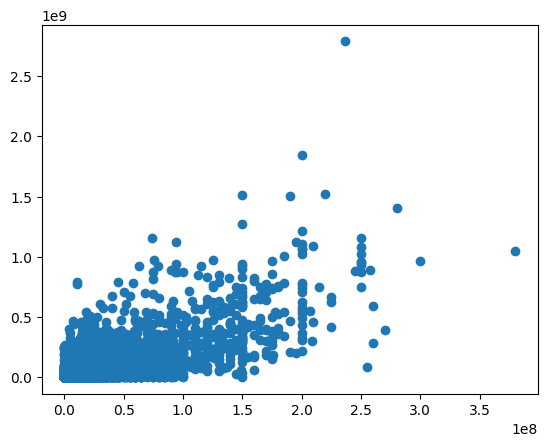

In [21]:
# Q5 : Is there a relation between budget and revenue ?
# We create a scatter plot to visualize the relationship between budget and revenue.
# This helps us understand if spending more money leads to higher revenue.
plt.scatter(df_EDA['budget'],df_EDA['revenue'])

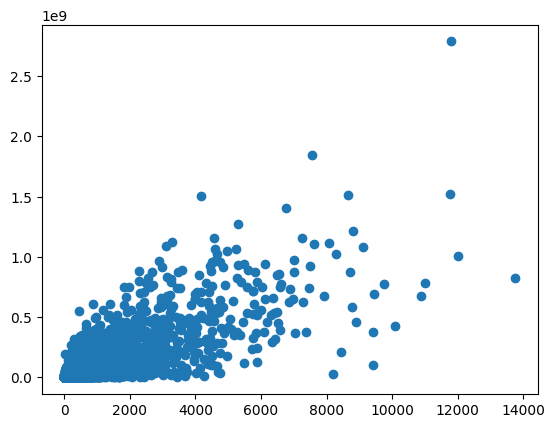

In [22]:
# Q6 : How are the vote count and revenue related?
# We create a scatter plot to visualize the relationship between vote count and revenue.
# This helps us understand if more popular movies (more votes) tend to earn more money.
plt.scatter(df_EDA['vote_count'],df_EDA['revenue'])

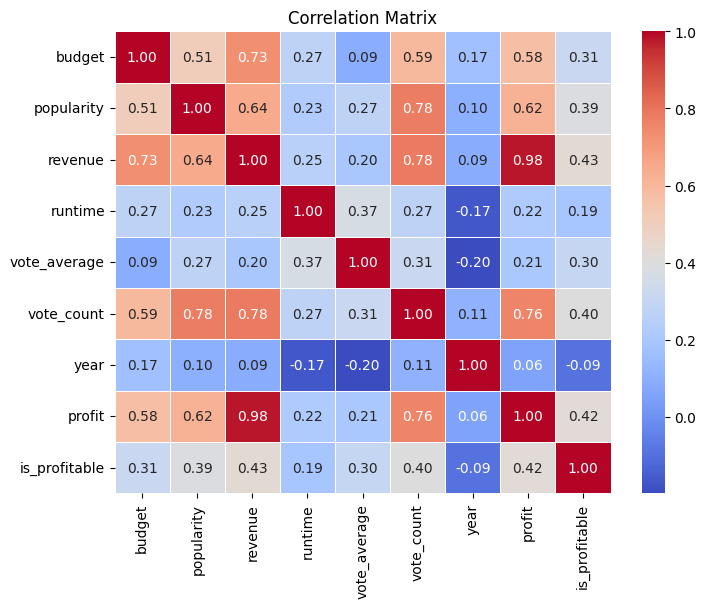

In [23]:
# Q7 : How the attributes are related?
# We compute the correlation matrix for the most important numerical columns.
# We then plot it as a heatmap to visually see which features are strongly related to each other.
# This is useful for understanding which features might be most useful for our model.
columns_for_corr = ['budget', 'popularity', 'revenue', 'runtime', 'vote_average', 'vote_count', 'year', 'profit', 'is_profitable']
df_EDA_corr = df_EDA[columns_for_corr]
correlation_matrix = df_EDA_corr.corr()
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Matrix')
plt.show()

Changes over years

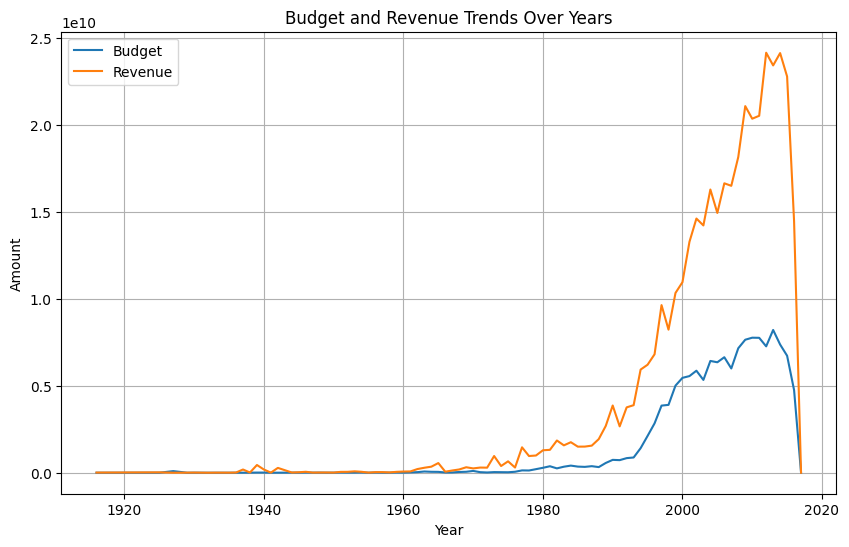

In [24]:
# Q8 : How have movie budget and revenue changed over time?
# We group movies by year and sum up the total budget and revenue for each year.
# We then plot both trends on the same graph to see how the industry has grown over time.
data_release_date = df_EDA.sort_values('year')
budget1 = data_release_date.groupby('year')['budget'].sum()
revenue1 = data_release_date.groupby('year')['revenue'].sum()
plt.figure(figsize=(10, 6))
plt.plot(budget1.index, budget1.values, label='Budget')
plt.plot(revenue1.index, revenue1.values, label='Revenue')
plt.title('Budget and Revenue Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Amount')
plt.legend()
plt.grid(True)

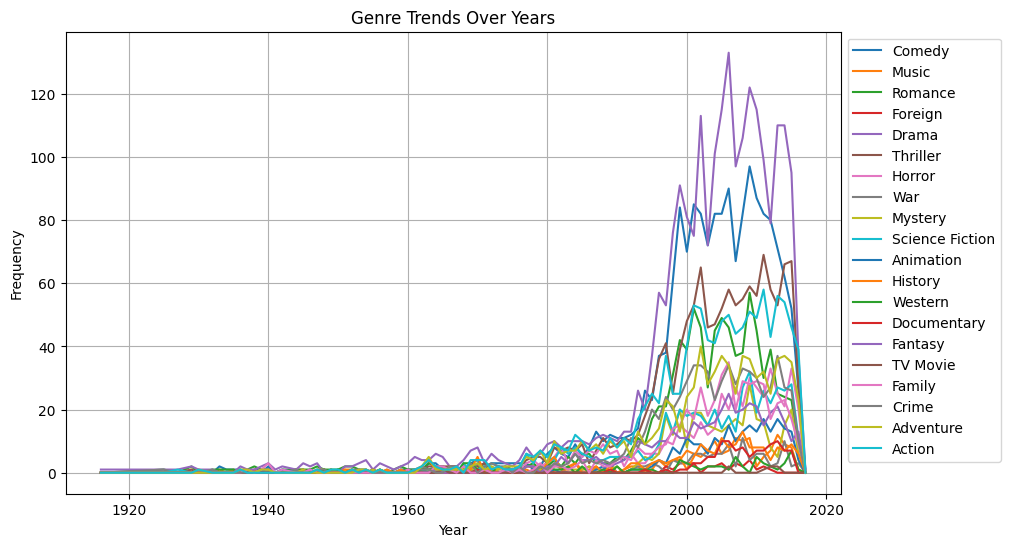

In [25]:
# Q9 : How the genre trends have changed throughout the years?
# We extract genres for each year and count how often each genre appears.
# We then plot trend lines for each genre to see how their popularity has changed over time.
genres_list = []
for genre_str in data_release_date['genres']:
    data = json.loads(genre_str)
    names = [item['name'] for item in data]
    genres_list.extend(names)
unique_genres = set(genres_list)
genre_counts = {genre: [] for genre in unique_genres}
for year in sorted(data_release_date['year'].unique()):
    year_data = data_release_date[data_release_date['year'] == year]
    genres_list = []
    for genre_str in year_data['genres']:
        data = json.loads(genre_str)
        names = [item['name'] for item in data]
        genres_list.extend(names)
    genres_list = {i : genres_list.count(i) for i in genres_list}
    for genre in unique_genres:
        try:
            genre_counts[genre].append(genres_list[genre])
        except KeyError:
            genre_counts[genre].append(0)
plt.figure(figsize=(10, 6))
for genre in unique_genres:
    plt.plot(data_release_date['year'].unique(), genre_counts[genre], label=genre)
plt.title('Genre Trends Over Years')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.grid(True)
plt.show()

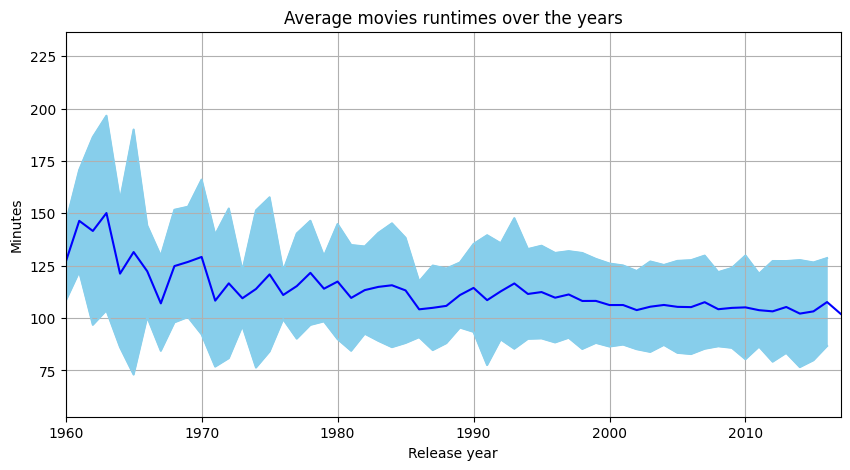

In [26]:
# Q10 : How the runtime of movies has changed over the years?
# We calculate the average runtime per year including standard deviation.
# We then plot the trend with a shaded area showing the range of runtimes.
# This helps us understand if movies have gotten shorter or longer over time.
grouped_data = df_EDA['runtime'].groupby(df_EDA['year']).describe()
avg_runtime_by_year = grouped_data['mean']
avg_runtime_min = grouped_data['mean'] - grouped_data['std']
avg_runtime_max = grouped_data['mean'] + grouped_data['std']
fig, x = plt.subplots(figsize=(10,5))
x.plot(avg_runtime_by_year, color='blue')
x.plot(avg_runtime_min, color='skyblue')
x.plot(avg_runtime_max, color='skyblue')
x.fill_between(grouped_data.index, avg_runtime_min, avg_runtime_max, color="skyblue")
x.set_title('Average movies runtimes over the years')
x.set_xlabel('Release year')
x.set_ylabel('Minutes')
x.set_xlim(1960,2017)
plt.grid(True)
plt.show()

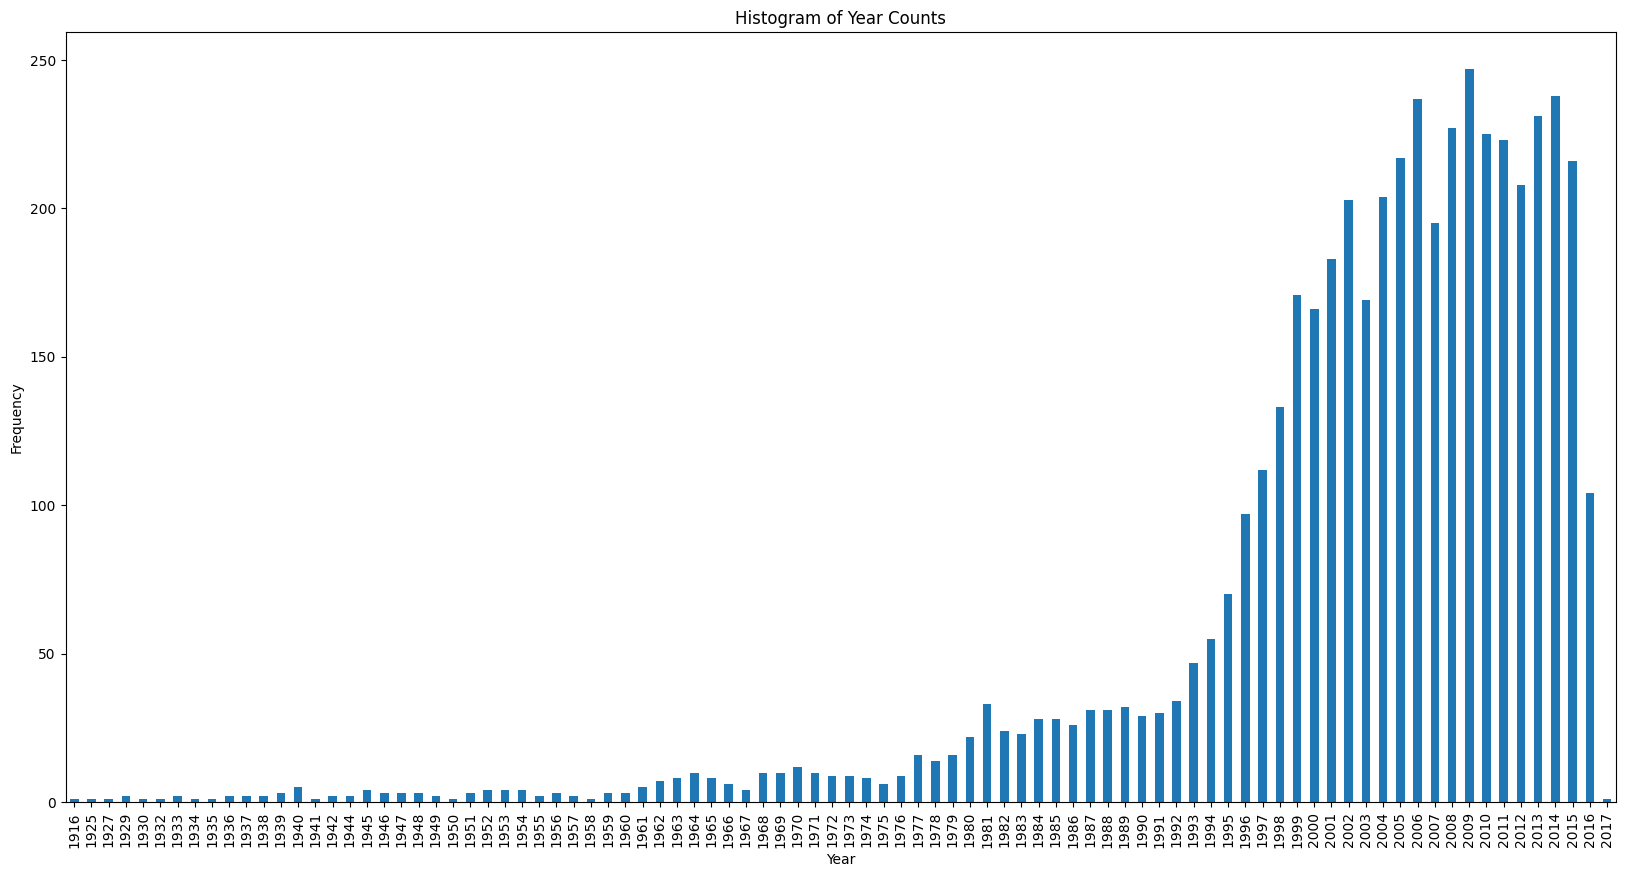

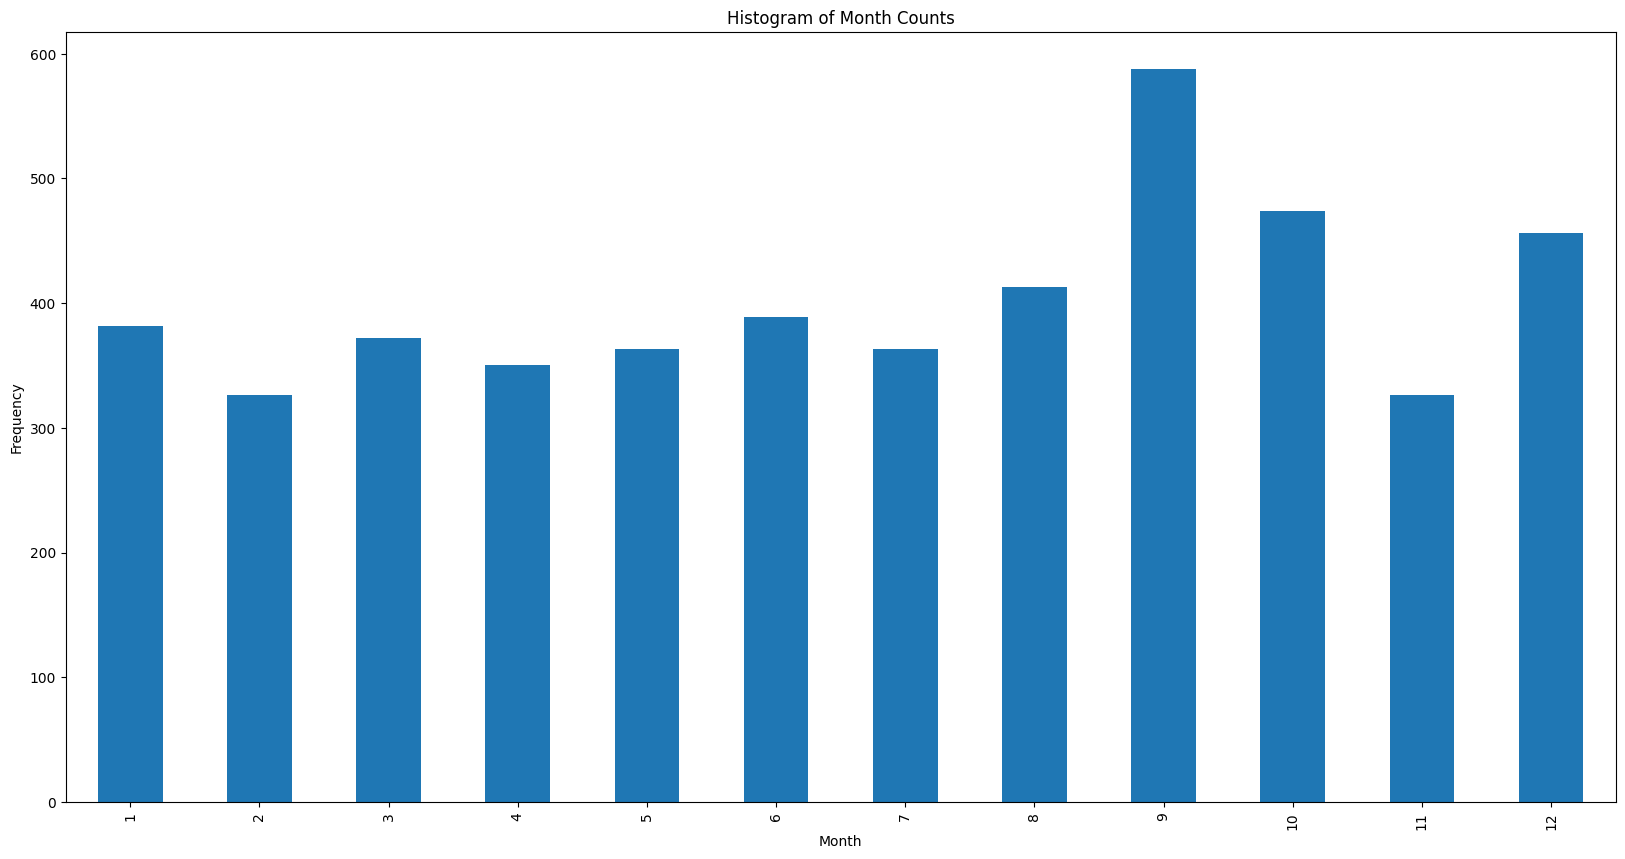

In [27]:
# Q11 : Which years/months has the number of movie releases?
# We count how many movies were released each year and each month.
# We then plot bar charts to see which periods had the most releases.
year_count = df_EDA.sort_values('year').groupby('year').size()
plt.figure(figsize=(20, 10))
year_count.plot(kind = 'bar')
plt.xticks(rotation= 90)
plt.title('Histogram of Year Counts')
plt.xlabel('Year')
plt.ylabel('Frequency')
plt.show()

df_EDA['month'] = df_EDA['release_date'].dt.month
month_count = df_EDA.groupby('month').size()
plt.figure(figsize=(20, 10))
month_count.plot(kind='bar')
plt.title('Histogram of Month Counts')
plt.xlabel('Month')
plt.ylabel('Frequency')
plt.show()

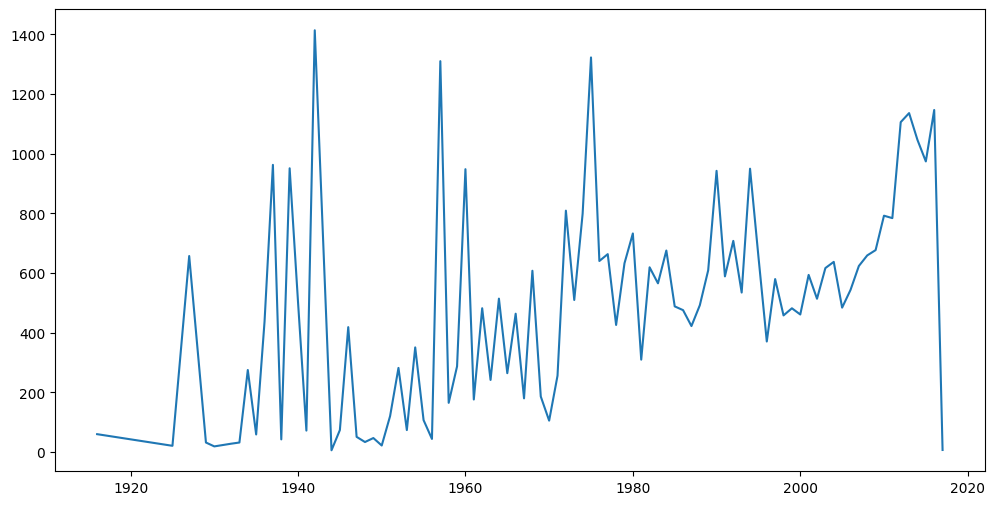

In [28]:
# Q12 : How the number of vote counts for movies have changed over the years?
# We calculate the average vote count per year and plot it as a line chart.
# This helps us understand if movie engagement has increased over time.
plt.figure(figsize=(12,6))
grouped_data = df_EDA.groupby('year')['vote_count'].mean()
plt.plot(grouped_data.index, grouped_data)
plt.show()

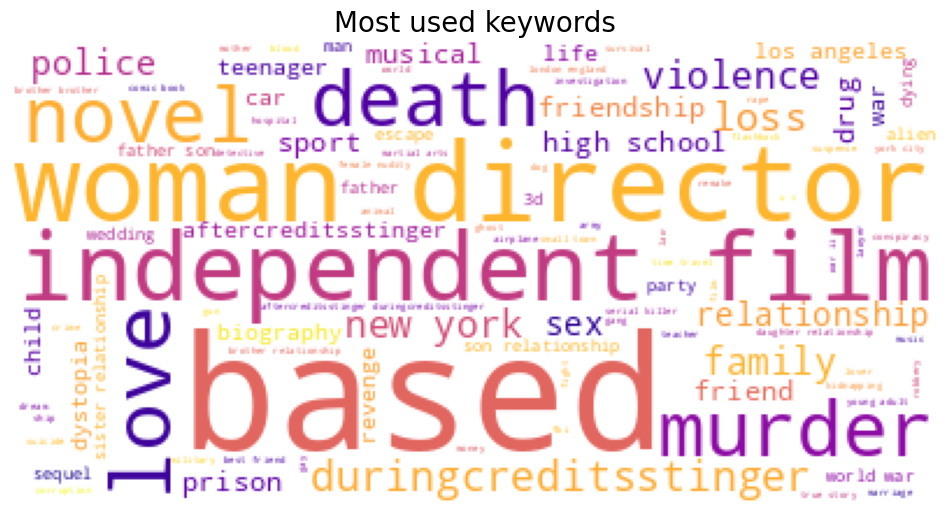

In [29]:
# Q13 : What are the most used keywords from the dataset?
# We extract all keywords from the JSON column and combine them into one text string.
# We then generate a word cloud to visually show the most frequently used keywords.
# Larger words appear more often in the dataset.
text = ','.join(' '.join([item['name'] for item in json.loads(keyword)]) for keyword in df_EDA['keywords'])
wc = WordCloud(max_words=100, background_color='white', colormap='plasma').generate(text)
plt.figure(figsize=(12,8))
plt.imshow(wc)
plt.title("Most used keywords", fontsize = 20)
plt.axis('off')
plt.show()

Cast and their Effects


In [30]:
# Q14 : Who are top 50 most popular actors?
# We go through every movie and accumulate the popularity score for each actor.
# The more popular movies an actor appears in the higher their cumulative popularity score.
# We then sort all actors by their score and select the top 50.
actors_popularity = {}
for index, row in df_EDA.iterrows():
    cast = json.loads(row['cast'])
    popularity = row['popularity']
    for actor in cast:
        actor_name = actor['name']
        actors_popularity[actor_name] = actors_popularity.get(actor_name, 0) + popularity
sorted_actors = sorted(actors_popularity.items(), key=lambda x: x[1], reverse=True)
top_50_actors = sorted_actors[:50]
top_50_name = []
for rank, (actor, popularity) in enumerate(top_50_actors, 1):
    print(f"Rank {rank}: {actor} - Cumulative Popularity: {popularity}")
    top_50_name.append(actor)

Rank 1: Stan Lee - Cumulative Popularity: 3148.7651520000004
Rank 2: Samuel L. Jackson - Cumulative Popularity: 2393.0473450000004
Rank 3: Matt Damon - Cumulative Popularity: 2324.211831000002
Rank 4: Morgan Freeman - Cumulative Popularity: 2144.355814000001
Rank 5: Geoffrey Rush - Cumulative Popularity: 2137.0505050000006
Rank 6: Johnny Depp - Cumulative Popularity: 2039.1833910000003
Rank 7: Michael Caine - Cumulative Popularity: 1898.682553
Rank 8: Bruce Willis - Cumulative Popularity: 1886.381318
Rank 9: Liam Neeson - Cumulative Popularity: 1855.6116000000002
Rank 10: Steve Carell - Cumulative Popularity: 1749.8587720000005
Rank 11: Brad Pitt - Cumulative Popularity: 1732.6732020000002
Rank 12: Anne Hathaway - Cumulative Popularity: 1605.035601
Rank 13: Gary Oldman - Cumulative Popularity: 1603.6700620000006
Rank 14: Steve Coogan - Cumulative Popularity: 1602.0252750000002
Rank 15: Ava Acres - Cumulative Popularity: 1584.745711
Rank 16: Tom Hanks - Cumulative Popularity: 1582.86127

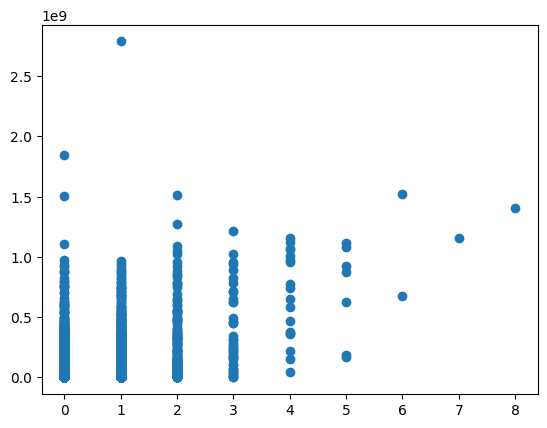

In [31]:
# Q15 : Do the count of popular actors affect the revenue?
# We create a new column that counts how many top 50 actors appear in each movie.
# We then create a scatter plot to see if having more popular actors leads to higher revenue.
df_EDA['in_top_50'] = df_EDA['cast'].apply(lambda x: sum(actor['name'] in top_50_name for actor in json.loads(x)))
plt.scatter(df_EDA['in_top_50'], df_EDA['revenue'])

Machine Learning and Modeling

In [32]:
# Defining Success
# We define a movie as successful if its profit is greater than or equal to
# the mean profit plus one standard deviation.
# This means we only consider movies that perform exceptionally well
# compared to all other movies in the dataset.
# Only around 8% of movies will be classified as successful using this definition.
df_ML = df_EDA.copy(deep = True)
mean_profit = df_ML['profit'].mean()
std_profit = df_ML['profit'].std()

def is_successful(profit):
    if profit >= mean_profit + std_profit:
        return 1
    return 0

df_ML['is_successful'] = df_ML['profit'].apply(is_successful)
success_rate = sum(df_ML['is_successful'] == 1) / len(df_ML) * 100
print(f"Success rate is {success_rate:.2f}%")

Success rate is 8.31%


In [33]:
# Feature Selection
# We select the columns we believe are most useful for predicting movie success.
# Budget, runtime, year and whether the movie has popular actors are our input features.
# is_successful is our target variable - what we want the model to predict.
columns_for_X = ['budget', 'runtime', 'year', 'in_top_50']
X = df_ML[columns_for_X]
y = df_ML['is_successful']

In [34]:
# Splitting the data into training and test sets.
# We use 80% of the data for training and 20% for testing.
# The model learns from the training set and is evaluated on the test set.
# random_state=0 ensures we get the same split every time we run the code.
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 0, stratify=y)

In [35]:
# Feature Scaling
# We use StandardScaler to scale all features to the same range.
# Without scaling budget (millions) would dominate over year or in_top_50 (small numbers).
# We fit the scaler only on training data to avoid data leakage.
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

Logistic Regression

In [36]:
# Model 1 - Logistic Regression
# Logistic Regression is our baseline model.
# It is simple and fast and gives us a reference point to compare the other models against.
# It predicts the probability of a movie being successful and classifies it as 1 or 0.
from sklearn.linear_model import LogisticRegression
classifier_logistic = LogisticRegression(random_state = 0)
classifier_logistic.fit(X_train, y_train)

LogisticRegression(random_state=0)

In [37]:
# We use the trained Logistic Regression model to make predictions on the test set.
y_pred = classifier_logistic.predict(X_test)
#print(np.concatenate((y_pred.reshape(len(y_pred),1), y_test.reshape(len(y_test),1)),1))


[[867  13]
 [ 52  29]]


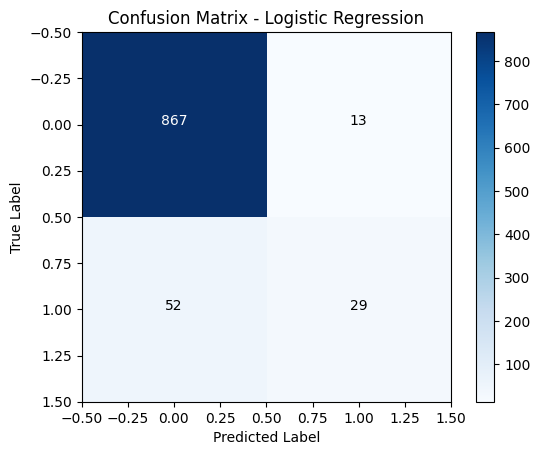

Accuracy:  0.9324
Precision: 0.6905
Recall:    0.3580
F1-Score:  0.4715


In [38]:
# Confusion Matrix - Logistic Regression
# The confusion matrix shows us how many predictions were correct and where the model made mistakes.
# It tells us how many successful movies the model correctly identified
# and how many it missed or incorrectly classified.
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

In [39]:
# Cross Validation - Logistic Regression
# We use 10-fold cross validation to get a more reliable estimate of model performance.
# This splits the data into 10 parts and trains and tests the model 10 times.
# The final accuracy is the average of all 10 runs.
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier_logistic, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))

Accuracy: 93.18 %
Standard Deviation: 0.52 %


Decision Tree

In [40]:
# Model 2 - Decision Tree
# Decision Tree makes predictions by learning simple yes/no decision rules from the data.
# It is easy to understand and visualize how it makes decisions.
# We use entropy as the criterion which measures the impurity of each split.
from sklearn.tree import DecisionTreeClassifier
classifier_dt = DecisionTreeClassifier(criterion = 'entropy', random_state = 0)
classifier_dt.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=0)

In [41]:
# We use the trained Decision Tree model to make predictions on the test set.
y_pred = classifier_dt.predict(X_test)

In [42]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support

[[858  22]
 [ 49  32]]


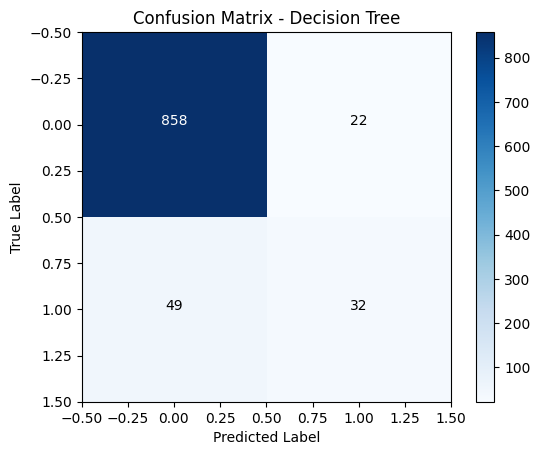

Accuracy:  0.9261
Precision: 0.5926
Recall:    0.3951
F1-Score:  0.4741


In [48]:
# Confusion Matrix - Decision Tree
# We evaluate the Decision Tree using the same metrics as Logistic Regression
# so we can compare the two models fairly.
cm = confusion_matrix(y_test, y_pred)
print(cm)
# Plot confusion matrix
plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix - Decision Tree')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
# Add text annotations

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.show()

accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1_score:.4f}")

Random Forest

[[862  18]
 [ 53  28]]


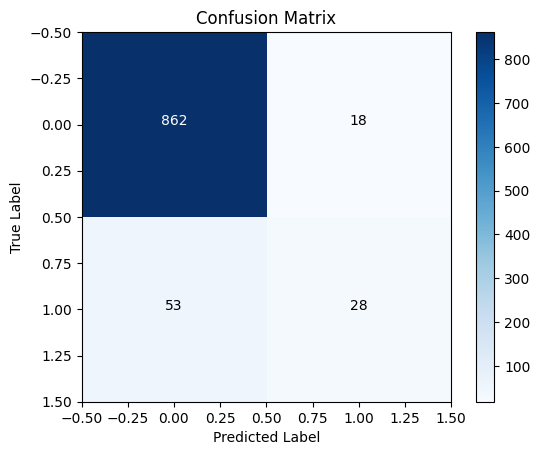

Accuracy: 0.9261
Precision: 0.6087
Recall: 0.3457
F1-Score: 0.4409


In [50]:
from sklearn.ensemble import RandomForestClassifier
classifier_rf = RandomForestClassifier(n_estimators = 10, criterion = 'entropy', random_state = 0)
classifier_rf.fit(X_train, y_train)
y_pred = classifier_rf.predict(X_test)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_recall_fscore_support
# Assuming y_test and y_pred are your test labels and predicted labels, respectively
cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.imshow(cm, cmap=plt.cm.Blues, interpolation='nearest')
plt.colorbar()
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
# Add text annotations
for i in range(cm.shape[0]):
 for j in range(cm.shape[1]):
  plt.text(j, i, format(cm[i, j], 'd'),
 horizontalalignment="center",
 color="white" if cm[i, j] > cm.max() / 2 else "black")
plt.show()
# Calculate additional metrics
accuracy = accuracy_score(y_test, y_pred)
precision, recall, f1_score, _ = precision_recall_fscore_support(y_test, y_pred, average='binary')
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1-Score: {f1_score:.4f}")




In [51]:
# Cross Validation - Random Forest
# We use 10-fold cross validation to evaluate Random Forest performance more reliably.
from sklearn.model_selection import cross_val_score
accuracies = cross_val_score(estimator = classifier_rf, X = X_train, y = y_train, cv = 10)
print("Accuracy: {:.2f} %".format(accuracies.mean()*100))
print("Standard Deviation: {:.2f} %".format(accuracies.std()*100))


Accuracy: 92.61 %
Standard Deviation: 0.99 %


ROC

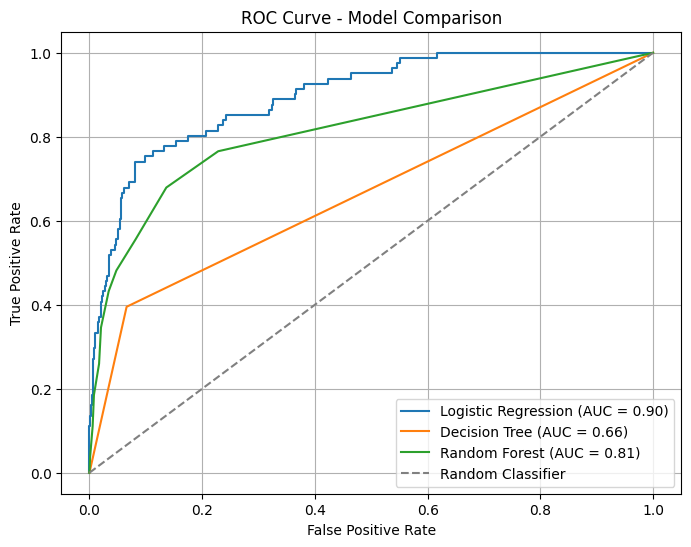

In [52]:
# ROC Curve - Model Comparison
# We plot the ROC curve for all three models to visually compare their performance.
# A curve closer to the top left corner means the model is better at distinguishing
# successful from non successful movies.
# The AUC score summarizes the overall performance - the closer to 1.0 the better.
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score
# We compare the ROC curves of all three models
# to evaluate which model best predicts movie success.
models = [classifier_logistic, classifier_dt, classifier_rf]
model_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
plt.figure(figsize=(8, 6))
for model, model_name in zip(models, model_names):
 y_pred_proba = model.predict_proba(X_test)[:, 1]
 fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
 auc_score = roc_auc_score(y_test, y_pred_proba)
 plt.plot(fpr, tpr, label=f'{model_name} (AUC = {auc_score:.2f})')
plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Model Comparison')
plt.legend(loc='lower right')
plt.grid(True)
plt.show()
